In [8]:
library(Seurat)
library(harmony)
library(spacexr)
library(Mfuzz)

library(ggplot2)
library(ggplotify)
library(ggsci)
library(scatterpie)
library(patchwork)
library(ggrastr)
library(scattermore)

library(ComplexHeatmap)
library(grid)
library(circlize)

library(Matrix)
library(dplyr)

In [2]:
source('../R_function/ST_plot.R')
source('../R_function/knn_function.R')
source('../R_function/calculate_function.R')

In [3]:
Class_color <- c('#F0E685FF','#CE3D32FF','#5DB1DDFF','#466983FF',
                 '#5050FFFF','#837B8DFF','#BA6338FF','#802268FF','#6BD76BFF','#D595A7FF','#924822FF','#749B58FF')
names(Class_color) <- c('GLU','CGE','MGE','LGE',
                        'AST','EPC','MG','NB','OLG','OPC','VLMC','EC')

Archr_col <- c('#D51F26','#272E6A','#208A42','#89288F','#F47D2B','#FEE500','#8A9FD1',
               '#C06CAB','#E6C2DC','#90D5E4','#89C75F','#F37B7D','#9983BD','#D24B27',
               '#3BBCA8','#6E4B9E','#0C727C','#7E1416','#D8A767')
Subclass_color <- Archr_col[1:17]
names(Subclass_color) <- c('MGE.PVALB','MGE.PVALB-POSTN','MGE.SST','CGE.VIP','CGE.LAMP5','CGE.LAMP5-PRKG1','CGE.LAMP5-RELN','CGE.RELN','LGE.TSHZ1','LGE.FOXP1',
                           'Upper-IT','Middle-IT','Deep-IT','Deep-CT','Deep-PT','Deep-NP','Deep-RGS12')

Species_color <- c('#2A6EBBFF','#F0AB00FF','#C50084FF','#7D5CC6FF','#E37222FF','#69BE28FF','#00B2A9FF')
names(Species_color) <- c('marm','mous','turt','turt','axol','lung','lamp')

In [4]:
obj_axol_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/Adult.rds')
obj_lung_ST_raw <- readRDS('/mnt/gandan/lishenglong/mut_sp/data/orig_data/03_anno.rds')

In [5]:
obj_axol_ST <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/ax_ctx_all_genename_OG.rds')
obj_lung_ST <- readRDS('/mnt/gandan/huangzhi/jupyter/Multispecies/Analysis/Region_defined/og_lf_brain.rds')
rotation_coor <- function(raw_df,rotation){
    r_pi <- rotation*pi/180
    r_matrix <- matrix(c(cos(r_pi),-sin(r_pi),
                         sin(r_pi),cos(r_pi)),ncol=2,nrow=2)
    r_df <- as.matrix(raw_df)%*%r_matrix
    return(r_df)
    }
obj_axol_ST@meta.data[,c('x_raw','y_raw')] <- obj_axol_ST@meta.data[,c('x','y')]
obj_lung_ST@meta.data[,c('x_raw','y_raw')] <- obj_lung_ST@meta.data[,c('x','y')]

obj_axol_ST@meta.data[,c('x','y')] <- rotation_coor(obj_axol_ST@meta.data[,c('x_raw','y_raw')],92)
obj_lung_ST@meta.data[,c('x','y')] <- rotation_coor(obj_lung_ST@meta.data[,c('x_raw','y_raw')],-135)

In [6]:
obj_axol_ST_raw$group <- paste0('AX_',round(obj_axol_ST_raw@images$Adult_telencephalon_rep2_DP8400015234BLA3_1@coordinates$col/25,0),'_',round(obj_axol_ST_raw@images$Adult_telencephalon_rep2_DP8400015234BLA3_1@coordinates$row/25,0))
obj_lung_ST_raw$group <- paste0('lf_',round(obj_lung_ST_raw$x/50,0),'_',round(obj_lung_ST_raw$y/50,0))

In [8]:
source('../R_function/calculate_function.R')

In [9]:
obj_axol_ST_raw_matrix <- matrix_groupby(obj_axol_ST_raw[['Spatial']]@counts,group.by = obj_axol_ST_raw$group,type = 'col',cal = 'sum')
obj_lung_ST_raw_matrix <- matrix_groupby(obj_lung_ST_raw[['RNA']]@counts,group.by = obj_lung_ST_raw$group,type = 'col',cal = 'sum')

In [10]:
obj_axol_ST[['RNA']] <- CreateAssayObject(obj_axol_ST_raw_matrix[,colnames(obj_axol_ST)])
obj_lung_ST[['RNA']] <- CreateAssayObject(obj_lung_ST_raw_matrix[,colnames(obj_lung_ST)])
obj_axol_ST <- NormalizeData(obj_axol_ST)
obj_lung_ST <- NormalizeData(obj_lung_ST)

In [11]:
obj_axol_ST@assays$RNA@meta.features <- obj_axol_ST_raw@assays$Spatial@meta.features

In [59]:
head(rownames(obj_lung_ST))

[1] "ND6"          "ND5"          "ND4"          "LOC122792163" "LOC122792048"
[6] "LOC122792042"

In [12]:
obj_axol_ST <- FindVariableFeatures(obj_axol_ST,nfeatures = 2000,verbose=FALSE)
obj_axol_ST <- ScaleData(obj_axol_ST,verbose=FALSE)
obj_axol_ST <- RunPCA(obj_axol_ST,npcs=30,verbose=FALSE)

In [13]:
obj_axol_ST <- RunUMAP(obj_axol_ST,dims=1:10,reduction = 'pca',verbose = F)
obj_axol_ST <- FindNeighbors(obj_axol_ST,reduction = 'pca',dims=1:10)
obj_axol_ST <- FindClusters(obj_axol_ST,resolution = 0.2)

Warning message:
“The default method for RunUMAP has changed from calling Python UMAP via reticulate to the R-native UWOT using the cosine metric
To use Python UMAP via reticulate, set umap.method to 'umap-learn' and metric to 'correlation'
This message will be shown once per session”
Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2346
Number of edges: 86974

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9061
Number of communities: 4
Elapsed time: 0 seconds


pdf 
  2

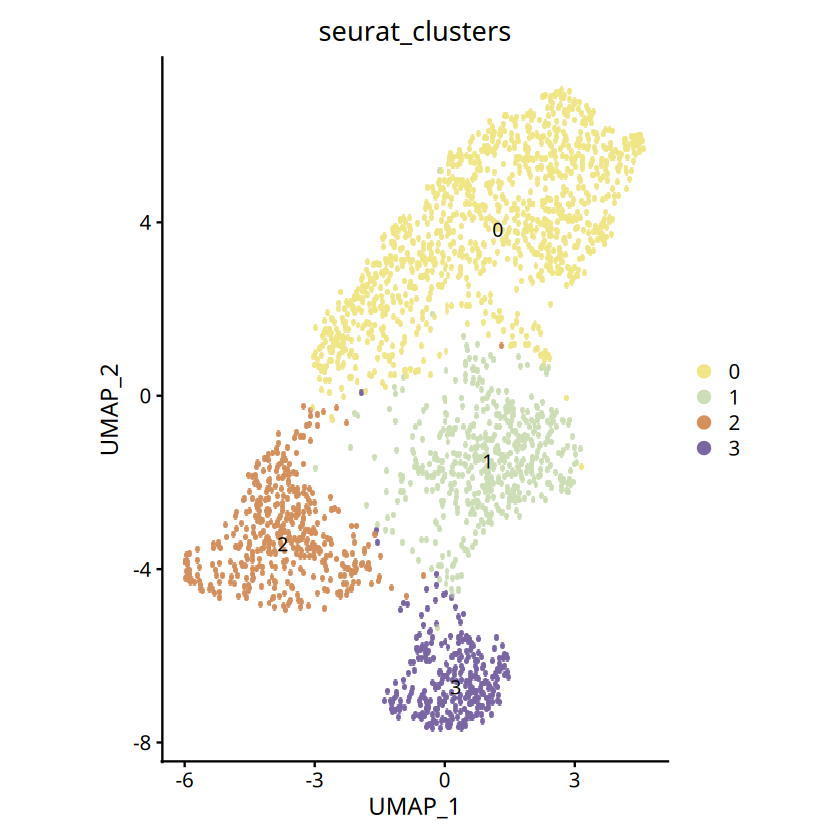

In [9]:
p <- DimPlot(obj_axol_ST,reduction = 'umap',group.by='seurat_clusters',pt.size = 3,raster=T,label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_axol_ST$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Axol_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

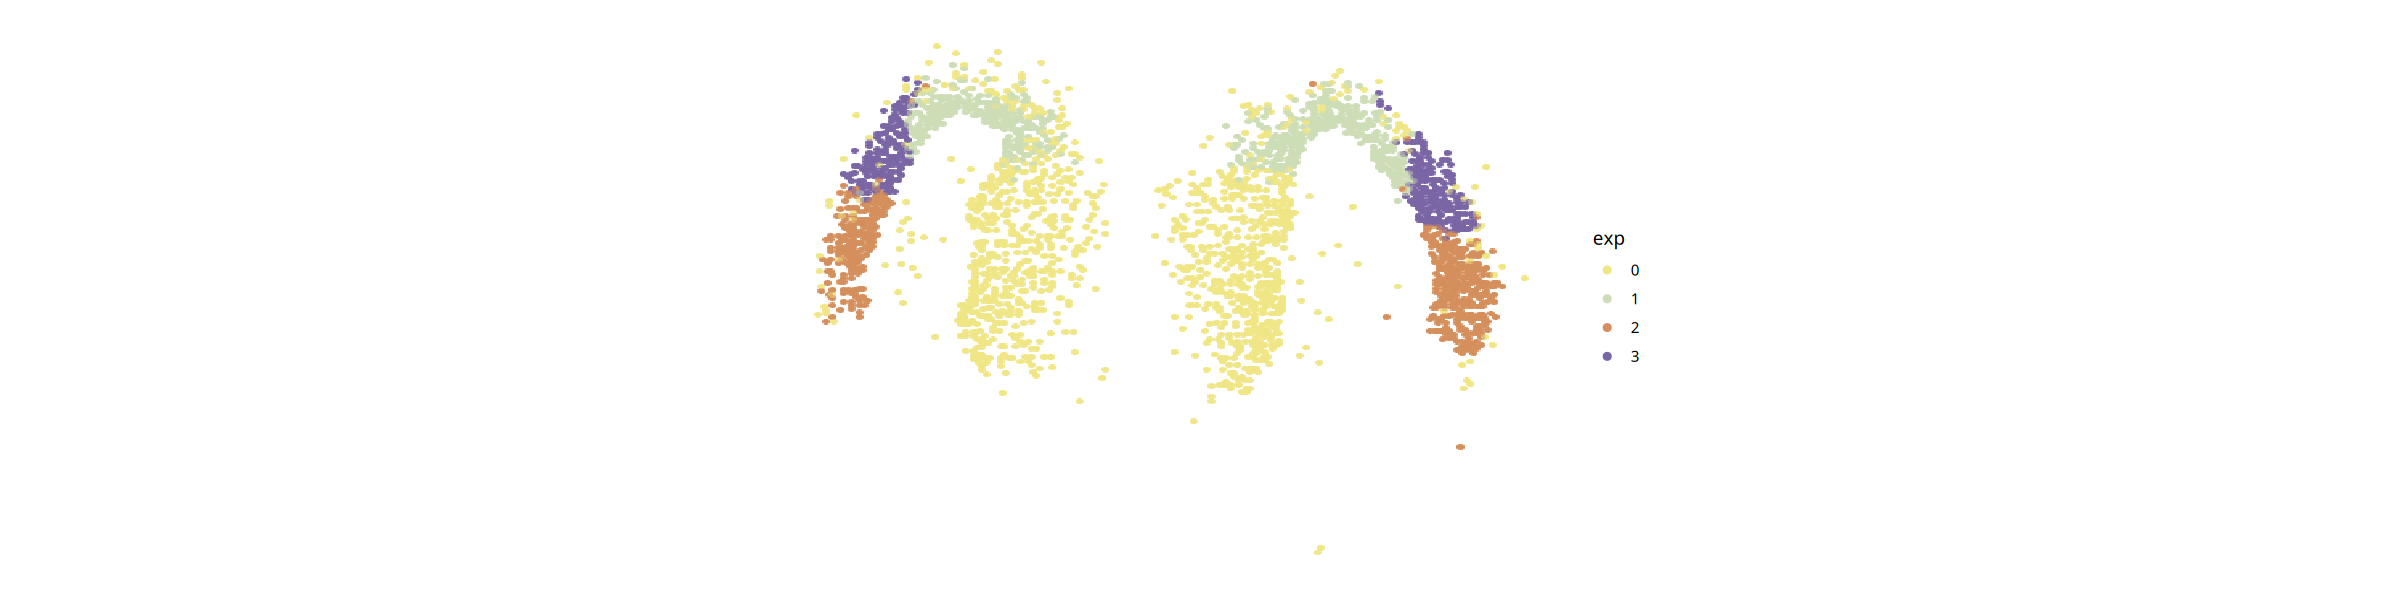

In [7]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_axol_ST$seurat_clusters)))
p1
pdf('Plot/Region_cluster/Axol_spatial_cluster.pdf',height = 5,width = 20)
p1
dev.off()

In [334]:
save_real_plot(save_plot=p1,dir_path = 'Plot/Region_mask/',name = 'axol_all',plot_x_vector = obj_axol_ST$x,plot_y_vector = obj_axol_ST$y,edge_add = 50)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


In [9]:
axol_mask <- read_real_mask_plot('Plot/Region_mask/axol_all_mask_-247.34_-19.36.tif',x_offset = -247.34, y_offset = -19.36)
axol_mask$region <- c('255'='MP','200'='DP','150'='LP','100'='LA')[as.character(axol_mask$mask)]
obj_axol_ST@meta.data <- df_add_mask(obj_axol_ST@meta.data,axol_mask,imputation = T,mask_col = 'region')

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

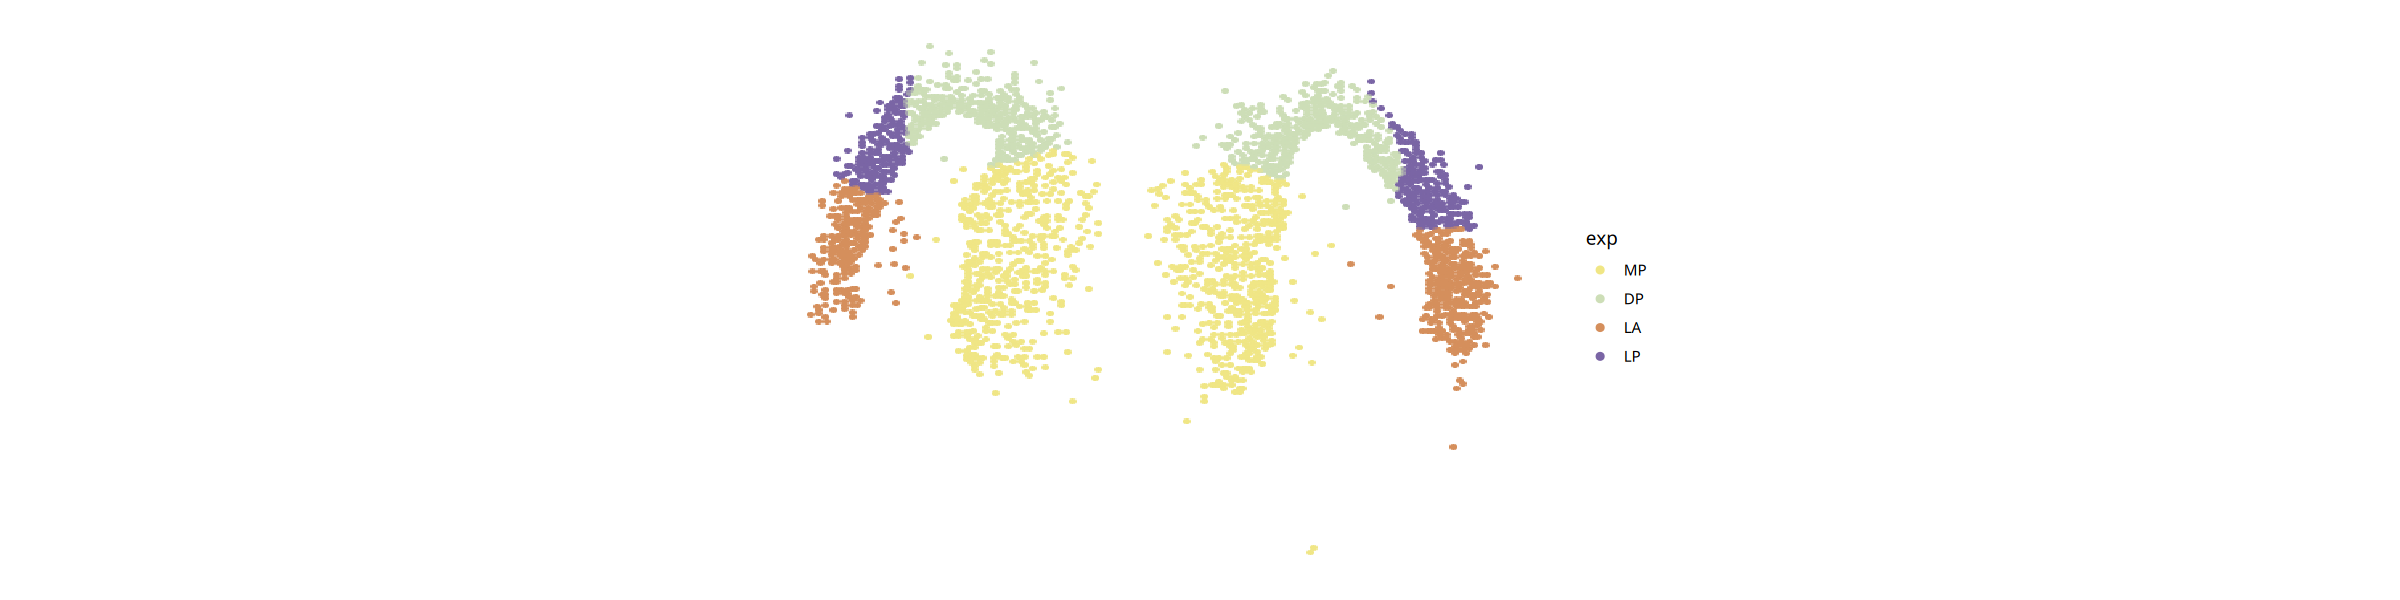

In [13]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = c('MP','DP','LA','LP'))
p1
pdf('Plot/Region_cluster/Axol_spatial_manual.pdf',height = 5,width = 20)
p1
dev.off()

In [16]:
saveRDS(obj_axol_ST,'Analysis/Region_defined/Gene_axol.rds')

In [3]:
obj_axol_ST <- readRDS('Analysis/Region_defined/Gene_axol.rds')

In [49]:
saveRDS( obj_axol_ST@reductions$pca,'Analysis/Region_defined/Axol_redcution.rds')

In [6]:
table(obj_axol_ST$region)


  dpEX   mpEX   mpIN nptxEX 
   528    626    347    845 

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


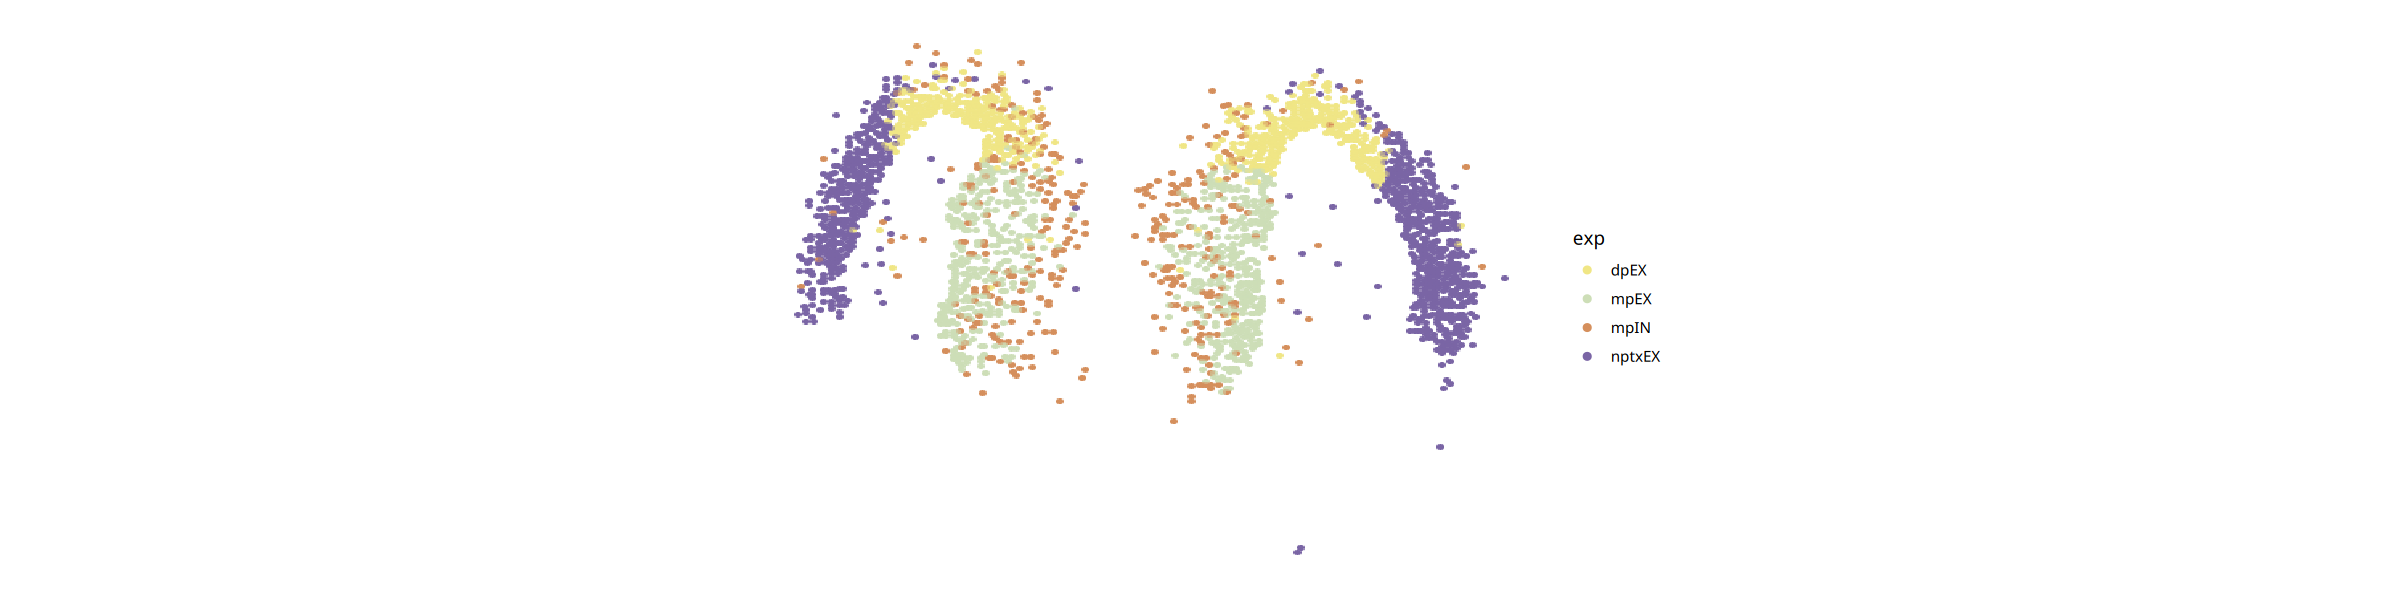

In [8]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)])
p1

In [56]:
obj_axol_ST <- readRDS('Analysis/Region_defined/Gene_axol.rds')

axol_mask <- read_real_mask_plot('Plot/Region_mask/axol_all_mask_-247.34_-19.36.tif',x_offset = -247.34, y_offset = -19.36)
#obj_axol_ST <- obj_axol_ST[,!obj_axol_ST$region%in%c('MP')]
obj_axol_ST <- obj_axol_ST[,!obj_axol_ST$seurat_clusters%in%c(0)]
axol_mask$region <- c('255'='MP','200'='DP','150'='LP','100'='LA')[as.character(axol_mask$mask)]
axol_mask <- axol_mask[ axol_mask$region!='MP',]
obj_axol_ST@meta.data <- df_add_mask(obj_axol_ST@meta.data,axol_mask,imputation = T,mask_col = 'region')
obj_axol_ST <- FindVariableFeatures(obj_axol_ST,nfeatures = 2000,verbose=FALSE)
obj_axol_ST <- ScaleData(obj_axol_ST,verbose=FALSE)
obj_axol_ST <- RunPCA(obj_axol_ST,npcs=30,verbose=FALSE)
obj_axol_ST <- RunUMAP(obj_axol_ST,dims=1:10,reduction = 'pca',verbose = F)
obj_axol_ST <- FindNeighbors(obj_axol_ST,reduction = 'pca',dims=1:10)
obj_axol_ST <- FindClusters(obj_axol_ST,resolution = 0.2)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1242
Number of edges: 48660

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9237
Number of communities: 3
Elapsed time: 0 seconds


Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


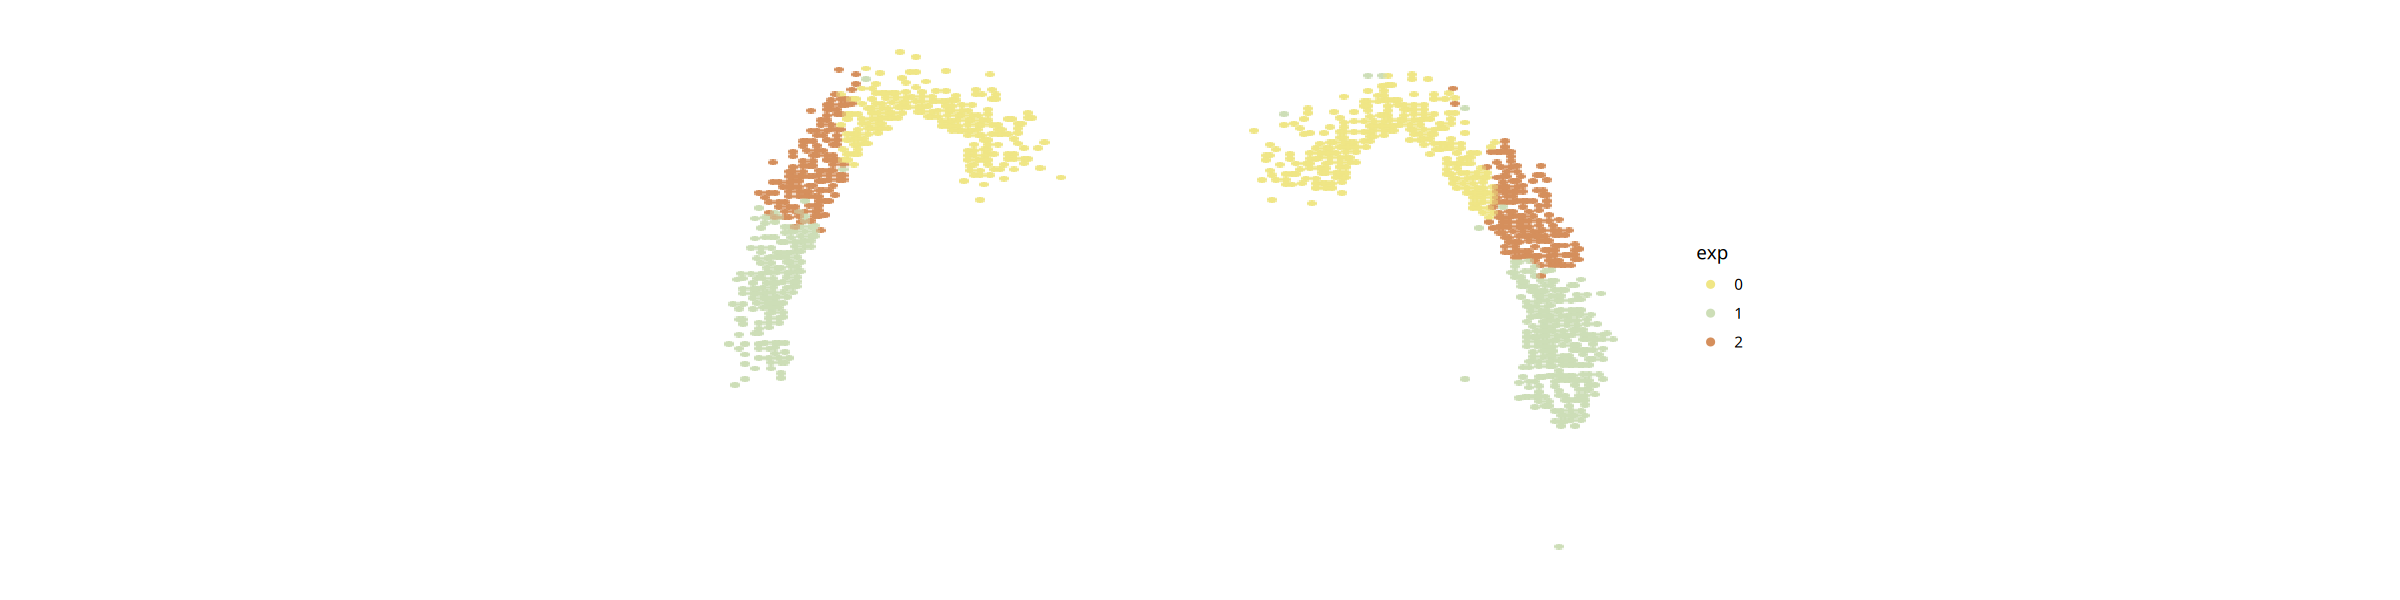

In [58]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_axol_ST$seurat_clusters)))
p1

pdf 
  2

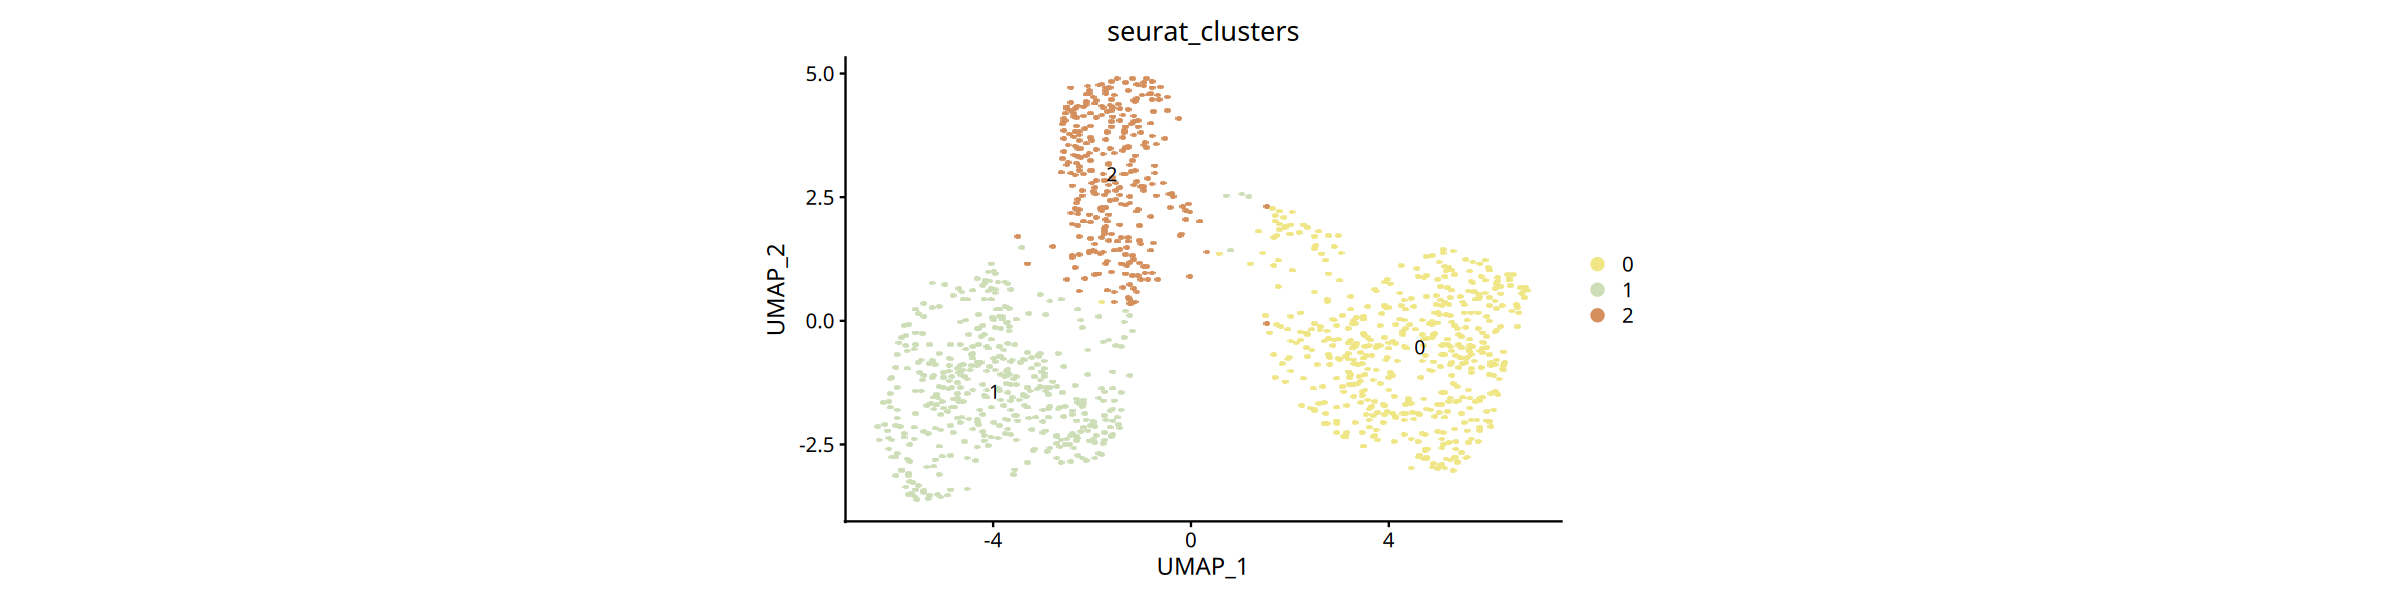

In [59]:
p <- DimPlot(obj_axol_ST,reduction = 'umap',group.by='seurat_clusters',pt.size = 3,raster=T,label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_axol_ST$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Axol_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

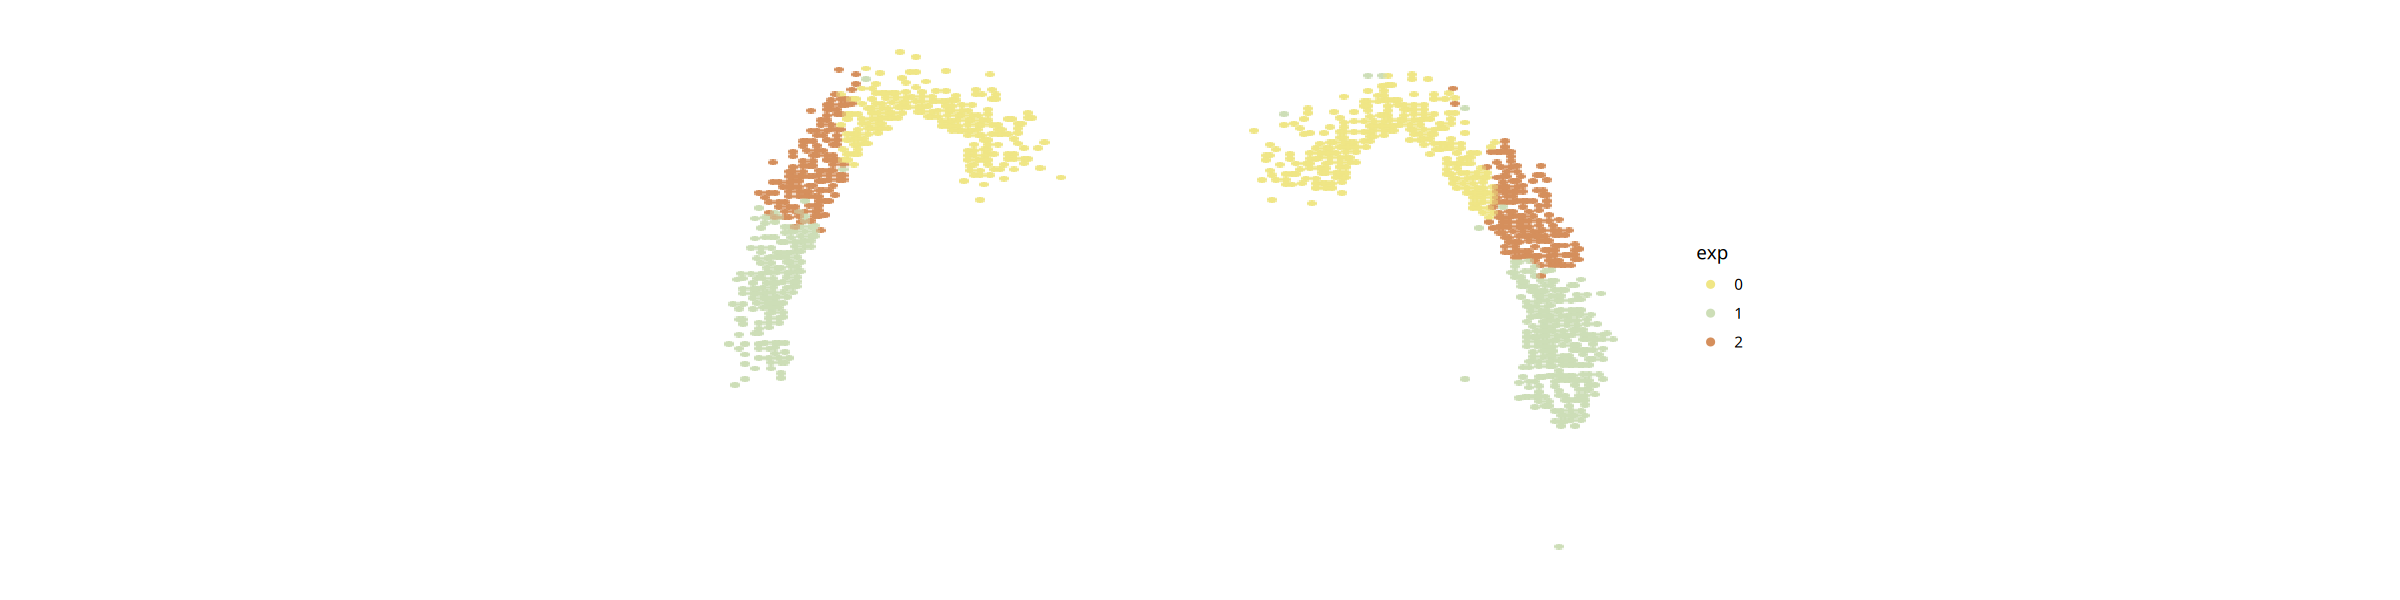

In [60]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_axol_ST$seurat_clusters)))
p1
pdf('Plot/Region_cluster/Axol_spatial_cluster.pdf',height = 5,width = 20)
p1
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

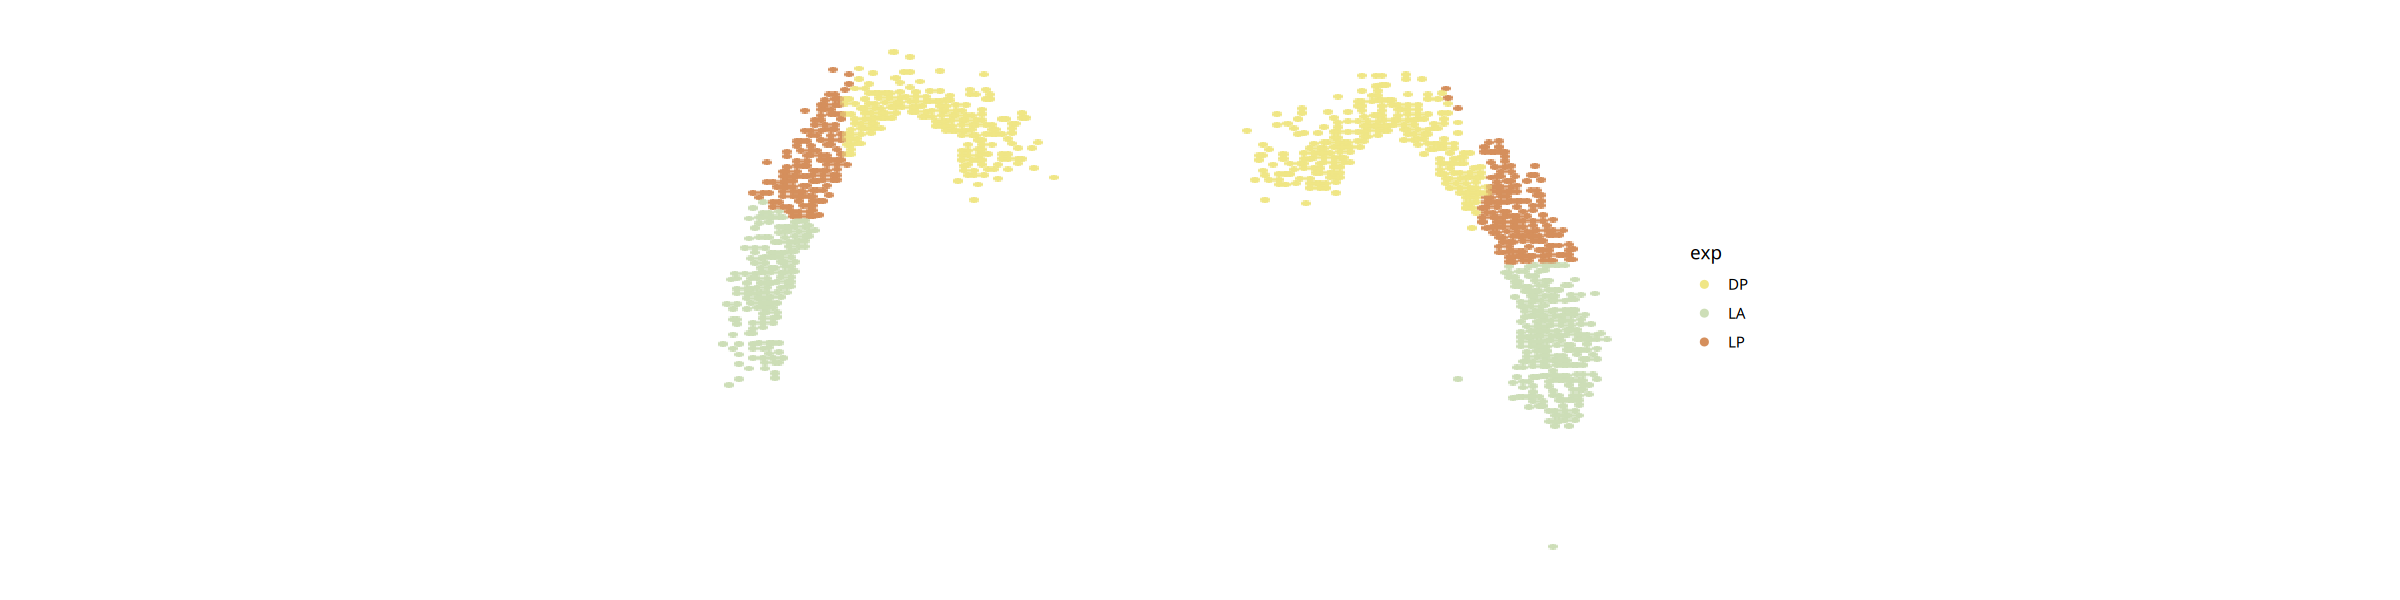

In [61]:
options(repr.plot.height=5,repr.plot.width=20)
p1 <- plot_spatial_col(obj = obj_axol_ST@meta.data,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = c('DP','LA','LP'))
p1
pdf('Plot/Region_cluster/Axol_spatial_manual.pdf',height = 5,width = 20)
p1
dev.off(

In [62]:
saveRDS(obj_axol_ST,'Analysis/Region_defined/Gene_axol_delMP.rds')

In [63]:
saveRDS( obj_axol_ST@reductions$pca,'Analysis/Region_defined/Redcution_axol_delMP.rds')

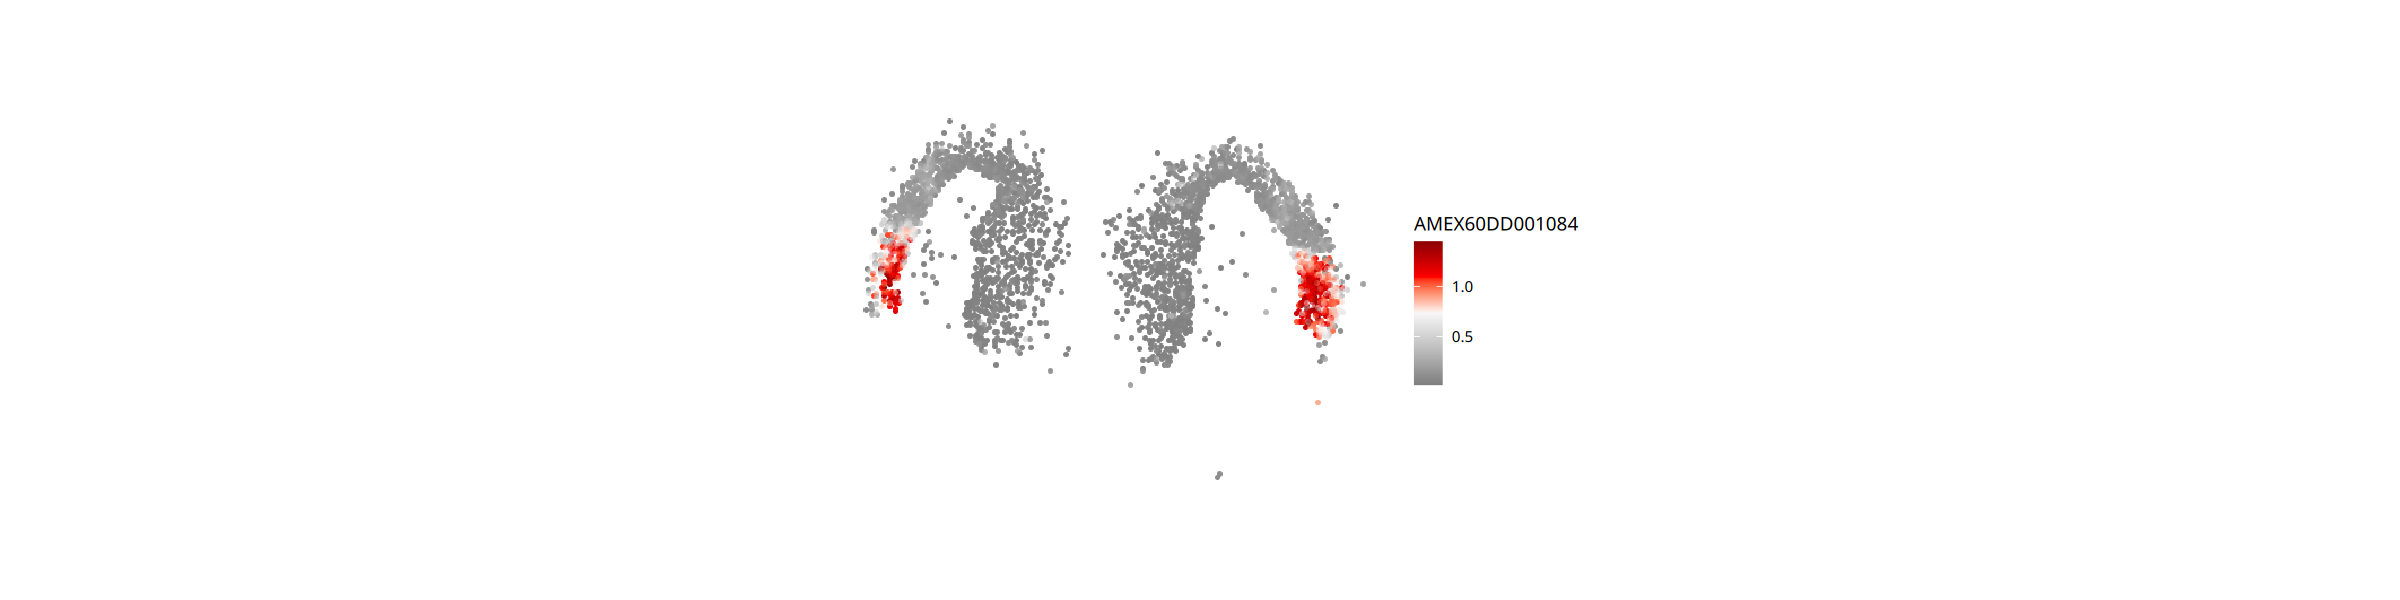

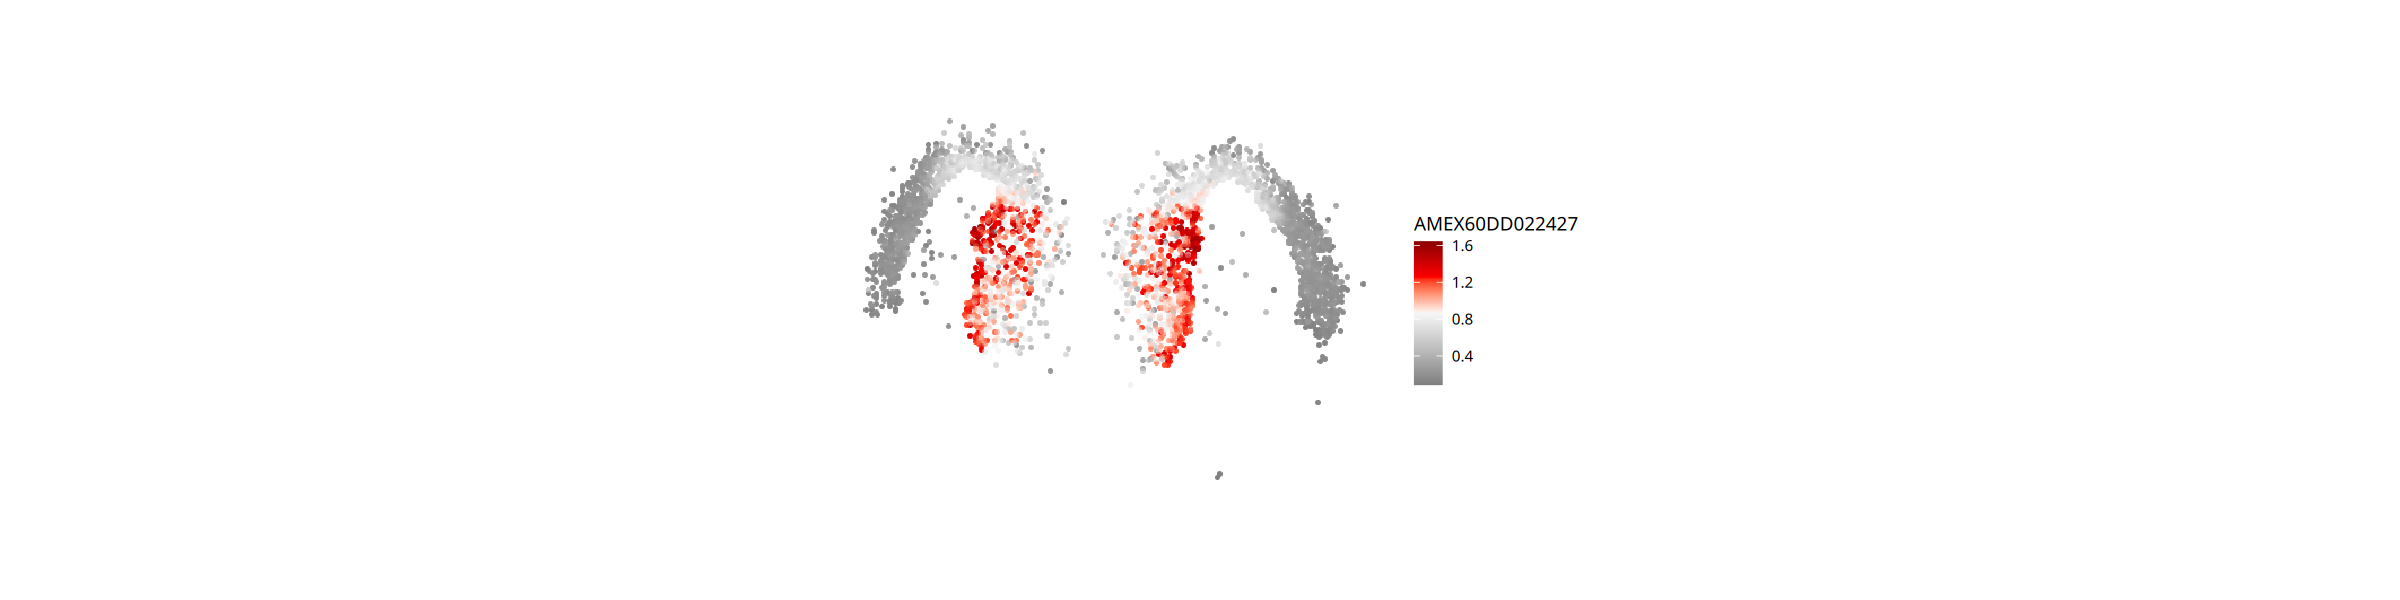

In [83]:
p1 <- plot_spatial_feature(obj = obj_axol_ST,features = 'AMEX60DD001084',height=200,assays='RNA',slot='data',smooth = T,knn=25,round=1,smooth_function='magic')
p2 <- plot_spatial_feature(obj = obj_axol_ST,features = 'AMEX60DD022427',height=200,assays='RNA',slot='data',smooth = T,knn=25,round=1,smooth_function='magic')
p1
p2

In [84]:
pdf('Plot/Region_gene_plot/Axol_NOS1.pdf',width=20,height = 5)
p1
dev.off()
pdf('Plot/Region_gene_plot/Axol_ETV1.pdf',width=20,height = 5)
p2
dev.off()

pdf 
  2

pdf 
  2

In [22]:
getwd()

[1] "/mnt/gandan/huangzhi/jupyter/Multispecies"

In [229]:
obj_lung_ST <- FindVariableFeatures(obj_lung_ST,nfeatures = 2000,verbose=FALSE)
obj_lung_ST <- ScaleData(obj_lung_ST,verbose=FALSE)
obj_lung_ST <- RunPCA(obj_lung_ST,npcs=30,verbose=FALSE)

In [243]:
obj_lung_ST <- RunUMAP(obj_lung_ST,dims=1:15,reduction = 'pca',verbose = F)
obj_lung_ST <- FindNeighbors(obj_lung_ST,reduction = 'pca',dims=1:15)
obj_lung_ST <- FindClusters(obj_lung_ST,resolution = 0.8)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5538
Number of edges: 167344

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.7104
Number of communities: 7
Elapsed time: 0 seconds


In [240]:
obj_lung_ST <- FindClusters(obj_lung_ST,resolution = 1.5)

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 5538
Number of edges: 166421

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6012
Number of communities: 10
Elapsed time: 0 seconds


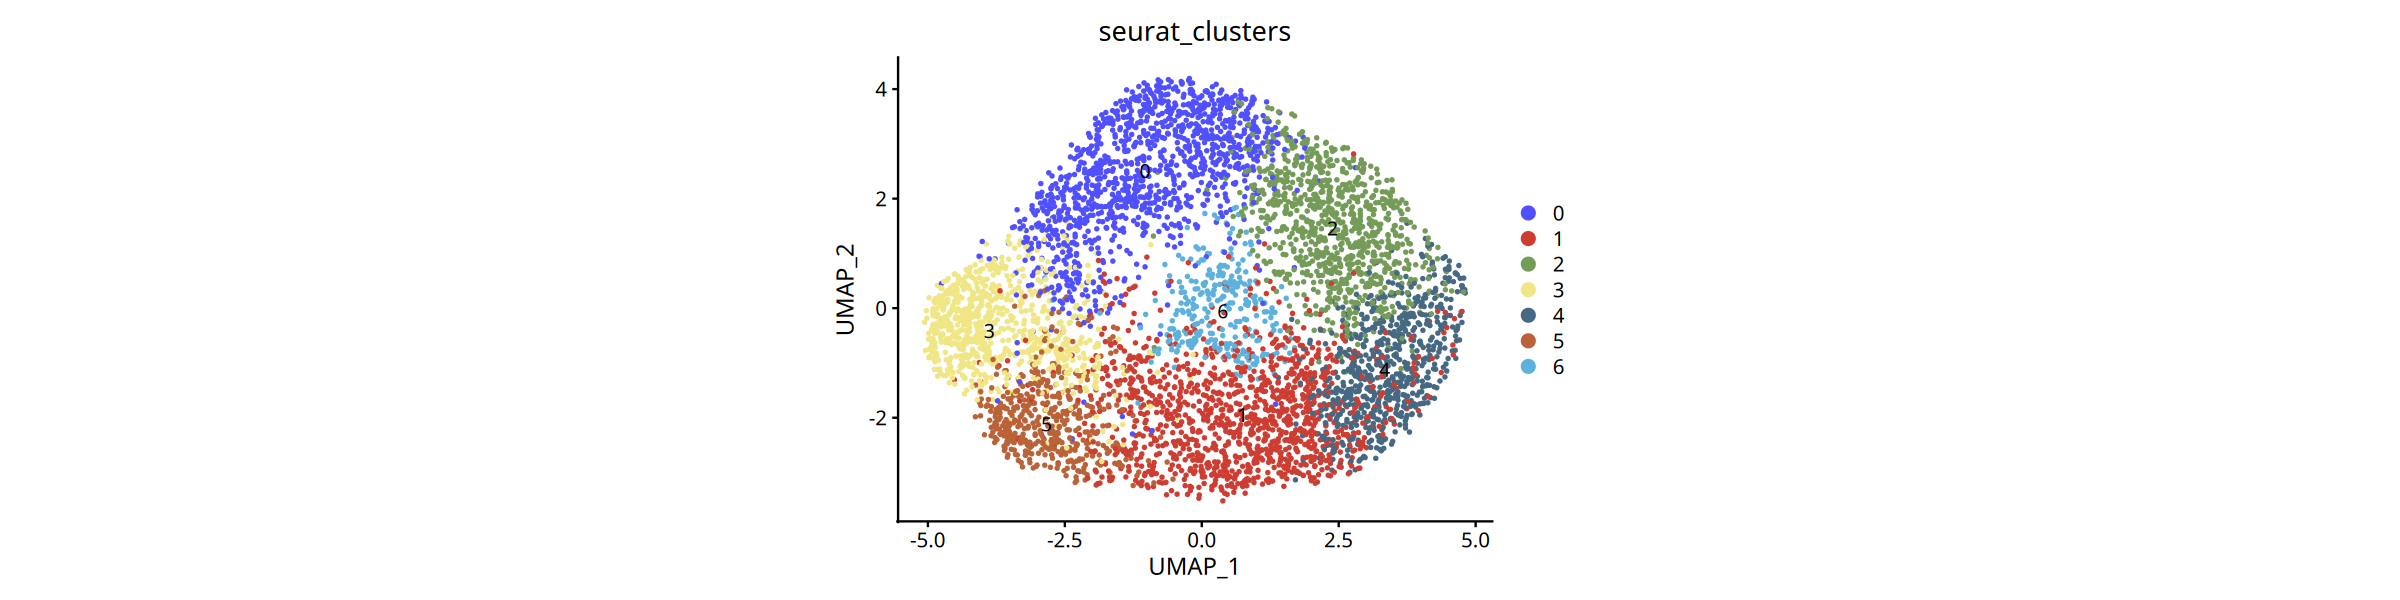

In [244]:
DimPlot(obj_lung_ST,reduction = 'umap',group.by='seurat_clusters',label=T)+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lung_ST$seurat_clusters)))+
coord_fixed()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


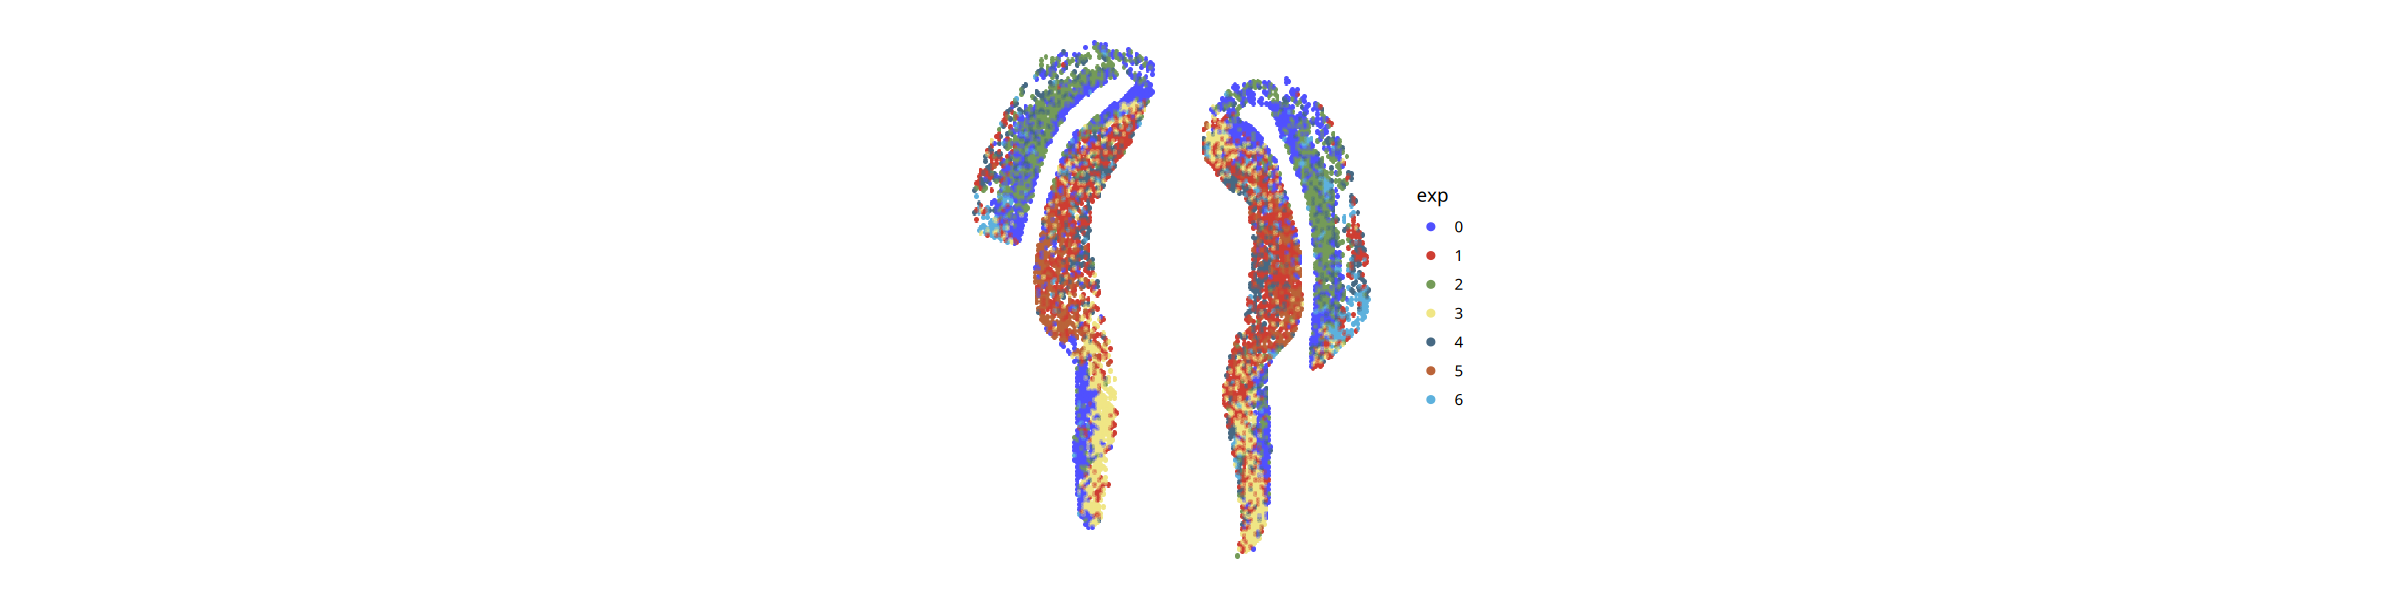

In [271]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lung_ST$seurat_clusters)))
p

In [273]:
source('../R_function/ST_plot.R')

In [274]:
save_real_plot(save_plot=p,dir_path = 'Plot/Region_mask/',name = 'lung_all',plot_x_vector = obj_lung_ST$x,plot_y_vector = obj_lung_ST$y,edge_add = 50)

Coordinate system already present.
ℹ Adding new coordinate system, which will replace the existing one.


In [276]:
lung_mask <- read_real_mask_plot('Plot/Region_mask/lung_all_mask_addMs_-132.73_-551.34.tif',x_offset = -132.73, y_offset = -551.34)
lung_mask$region <- c('255'='Ms','200'='MP','150'='DP','100'='LP','75'='LA')[as.character(lung_mask$mask)]
obj_lung_ST@meta.data <- df_add_mask(obj_lung_ST@meta.data,lung_mask,imputation = T,mask_col = 'region')
obj_lung_ST <- obj_lung_ST[,obj_lung_ST$region!='Ms']

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


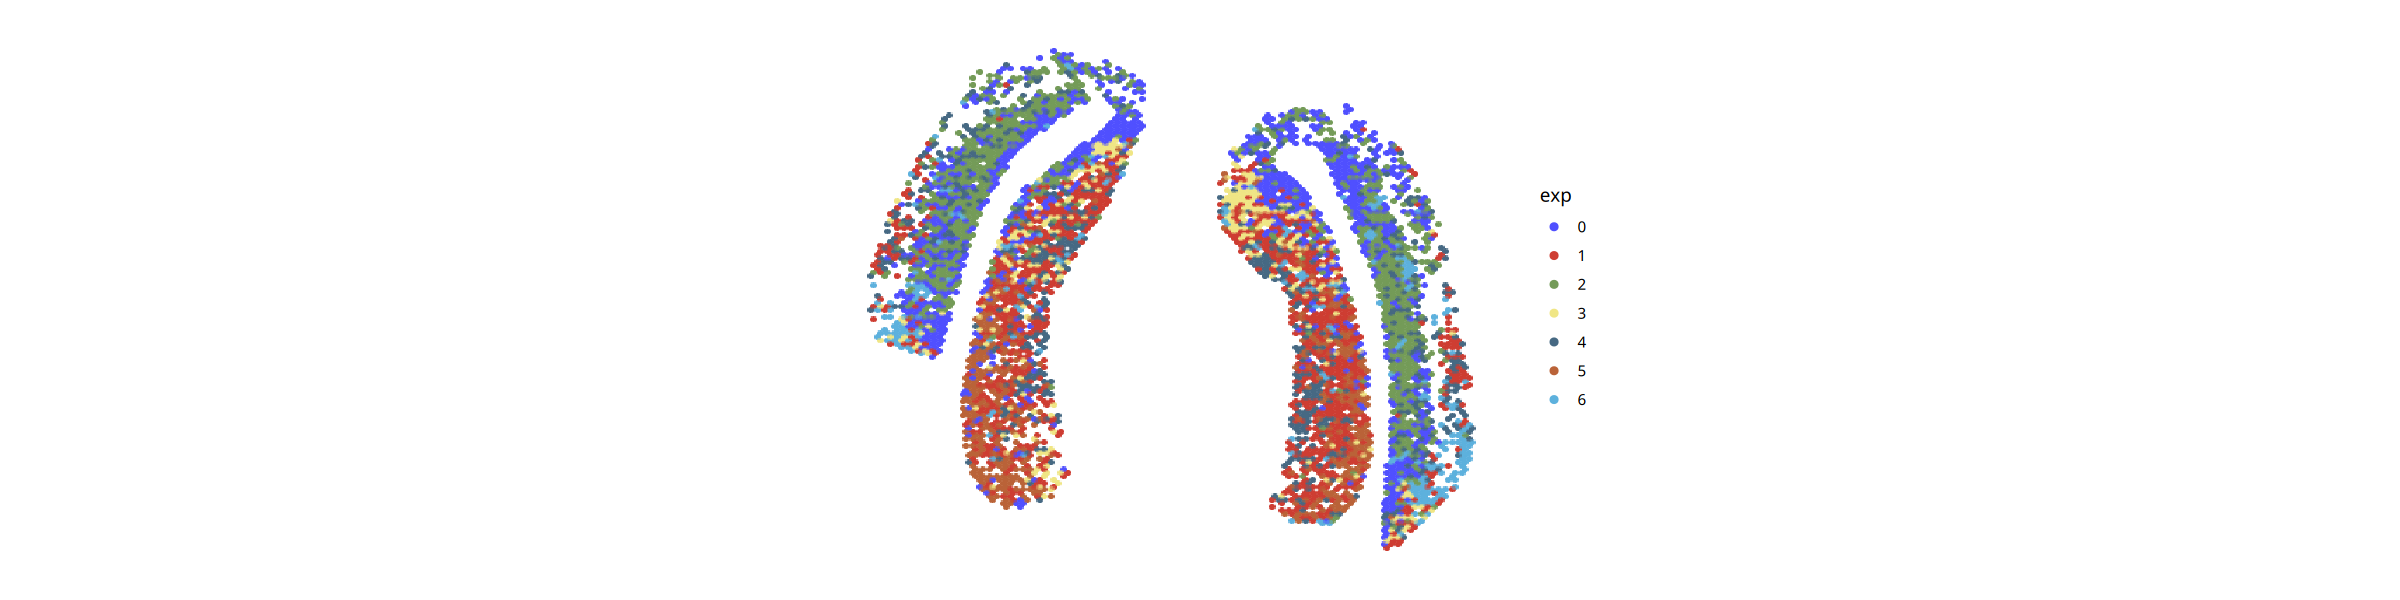

In [279]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50),breaks = sort(unique(obj_lung_ST$seurat_clusters)))
p

In [318]:
obj_lung_ST <- FindVariableFeatures(obj_lung_ST,nfeatures = 1500,verbose=FALSE)
obj_lung_ST <- ScaleData(obj_lung_ST,verbose=FALSE)
obj_lung_ST <- RunPCA(obj_lung_ST,npcs=30,verbose=FALSE)
obj_lung_ST <- RunUMAP(obj_lung_ST,dims=1:15,reduction = 'pca',verbose = F)
obj_lung_ST <- FindNeighbors(obj_lung_ST,reduction = 'pca',dims=1:15)
obj_lung_ST <- FindClusters(obj_lung_ST,resolution = 0.8)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 4282
Number of edges: 133265

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6839
Number of communities: 6
Elapsed time: 0 seconds


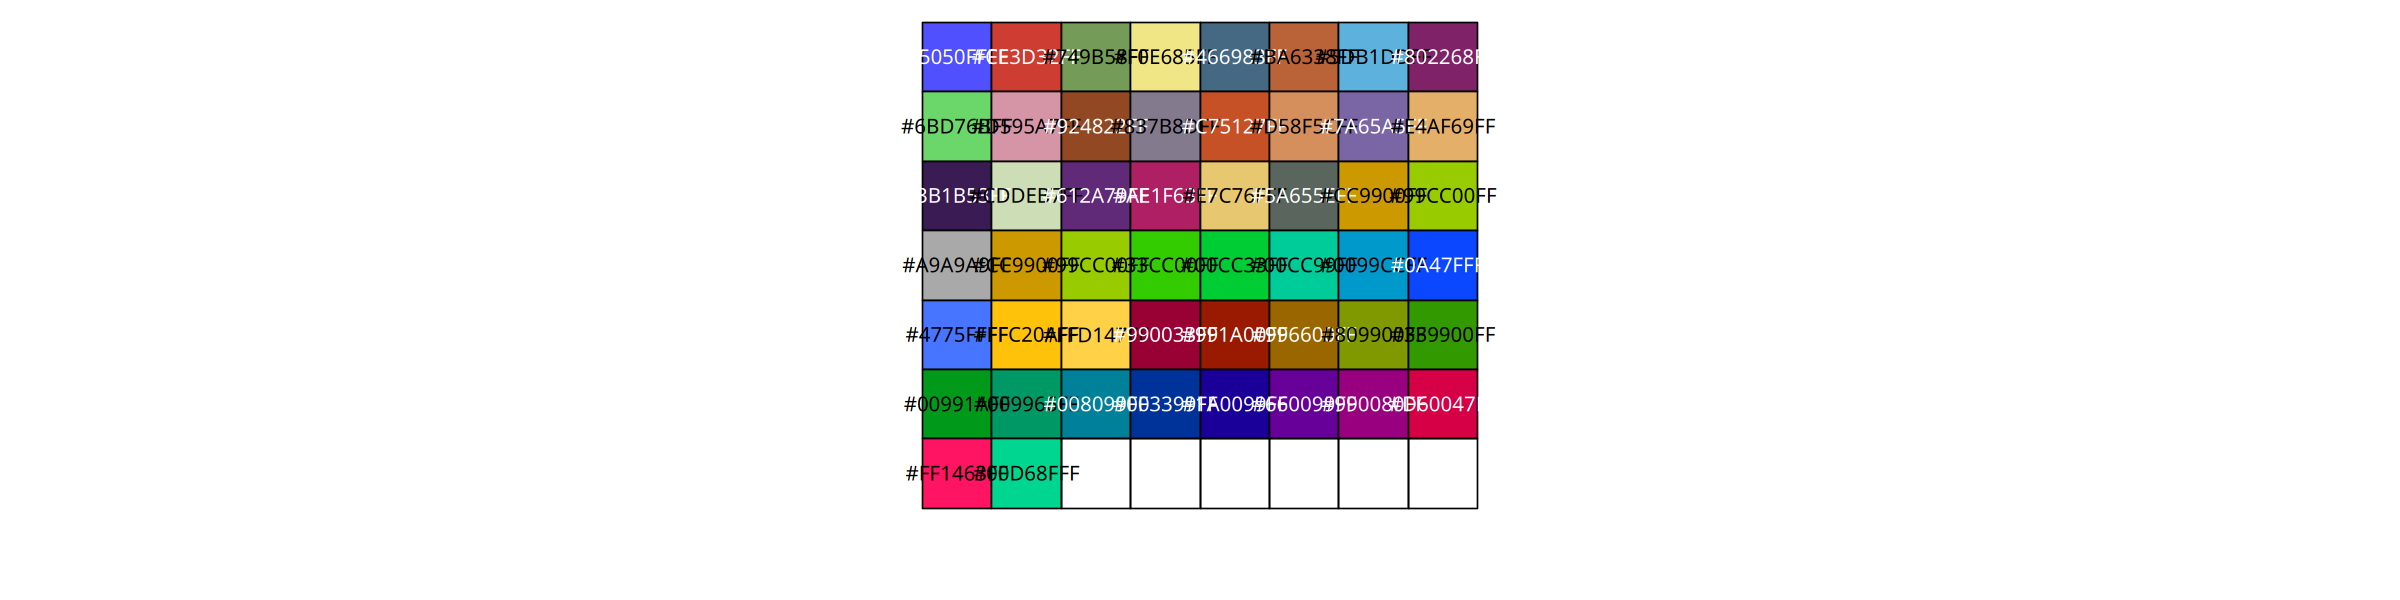

In [302]:
scales::show_col(pal_igv()(50))

pdf 
  2

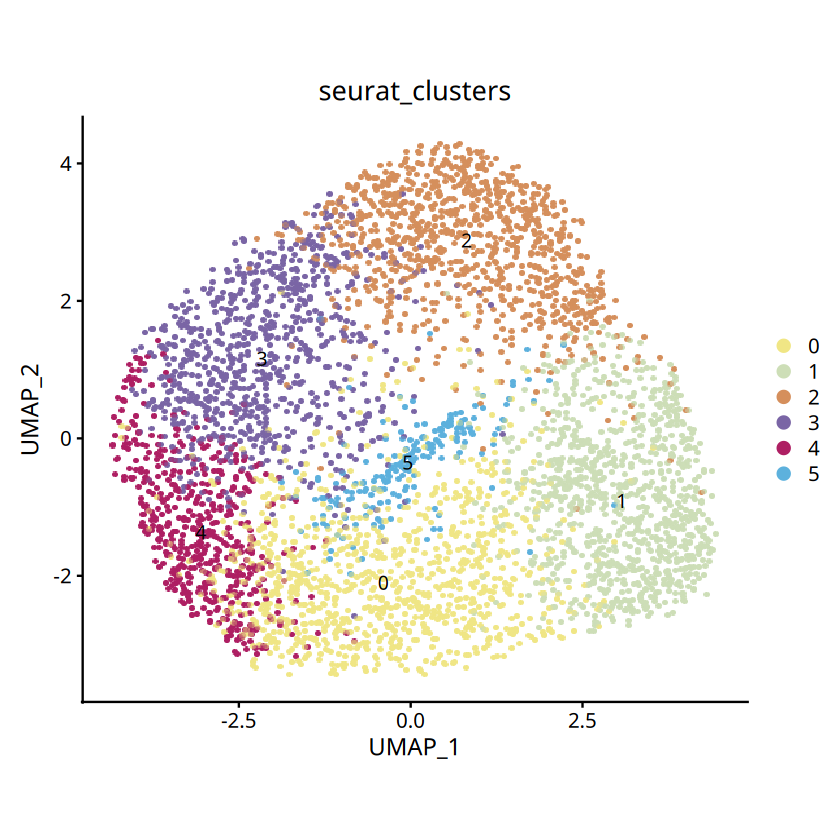

In [6]:
p <- DimPlot(obj_lung_ST,reduction = 'umap',group.by='seurat_clusters',pt.size = 3,raster=T,label=T)+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_lung_ST$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Lung_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

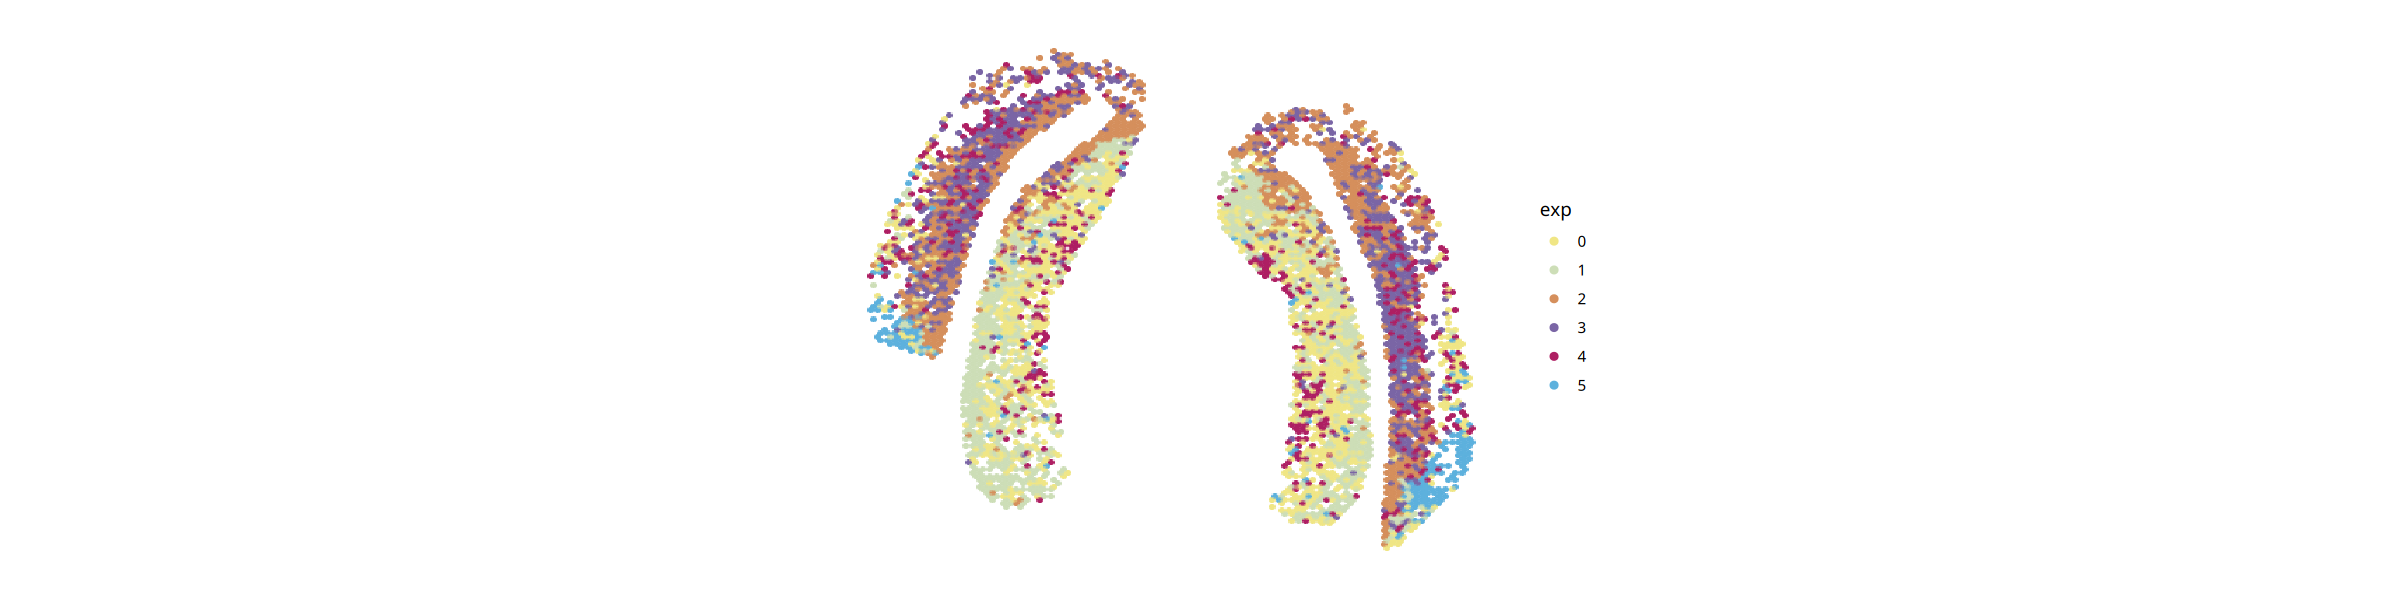

In [17]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(4,18,14,15,20,7)],breaks = sort(unique(obj_lung_ST$seurat_clusters)))
p
pdf('Plot/Region_cluster/Lung_spatial_cluster.pdf',height = 5,width = 20)
p
dev.off()

In [18]:
lung_mask <- read_real_mask_plot('Plot/Region_mask/lung_all_mask_-132.73_-551.34.tif',x_offset = -132.73, y_offset = -551.34)
lung_mask$region <- c('200'='MP','150'='DP','100'='LP','75'='LA')[as.character(lung_mask$mask)]
obj_lung_ST@meta.data <- df_add_mask(obj_lung_ST@meta.data,lung_mask,imputation = T,mask_col = 'region')
obj_lung_ST <- obj_lung_ST[,obj_lung_ST$region!='Ms']

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

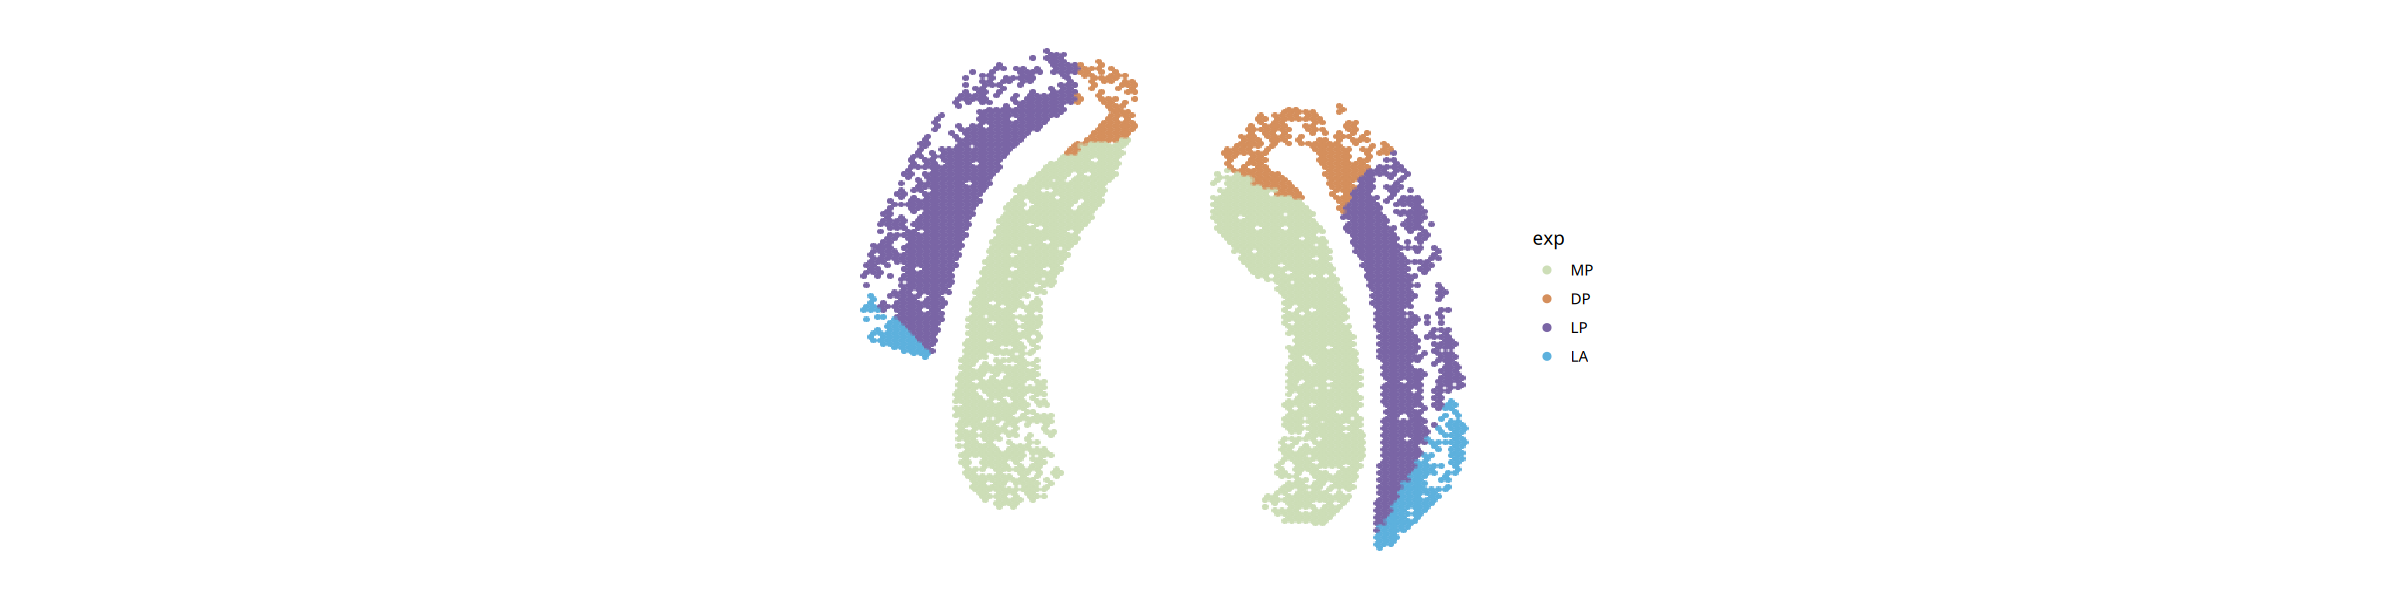

In [22]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(18,14,15,7)],breaks = c('MP','DP','LP','LA'))
p
pdf('Plot/Region_cluster/Lung_spatial_manual.pdf',height = 5,width = 20)
p
dev.off()

In [325]:
saveRDS(obj_lung_ST,'Analysis/Region_defined/Gene_lung.rds')

In [5]:
obj_lung_ST <- readRDS('Analysis/Region_defined/Gene_lung.rds')

In [47]:
saveRDS( obj_lung_ST@reductions$pca,'Analysis/Region_defined/Redcution_lung.rds')

In [32]:
obj_lung_ST <- readRDS('Analysis/Region_defined/Gene_lung.rds')
obj_lung_ST <- obj_lung_ST[,obj_lung_ST$region!='MP']
obj_lung_ST <- FindVariableFeatures(obj_lung_ST,nfeatures = 1500,verbose=FALSE)
obj_lung_ST <- ScaleData(obj_lung_ST,verbose=FALSE)
obj_lung_ST <- RunPCA(obj_lung_ST,npcs=30,verbose=FALSE)
obj_lung_ST <- RunUMAP(obj_lung_ST,dims=1:15,reduction = 'pca',verbose = F)
obj_lung_ST <- FindNeighbors(obj_lung_ST,reduction = 'pca',dims=1:15)
obj_lung_ST <- FindClusters(obj_lung_ST,resolution = 0.8)

Computing nearest neighbor graph

Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 2143
Number of edges: 74870

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.6290
Number of communities: 5
Elapsed time: 0 seconds


In [4]:
obj_lung_ST <- readRDS('Analysis/Region_defined/Gene_lung_delMP.rds')

pdf 
  2

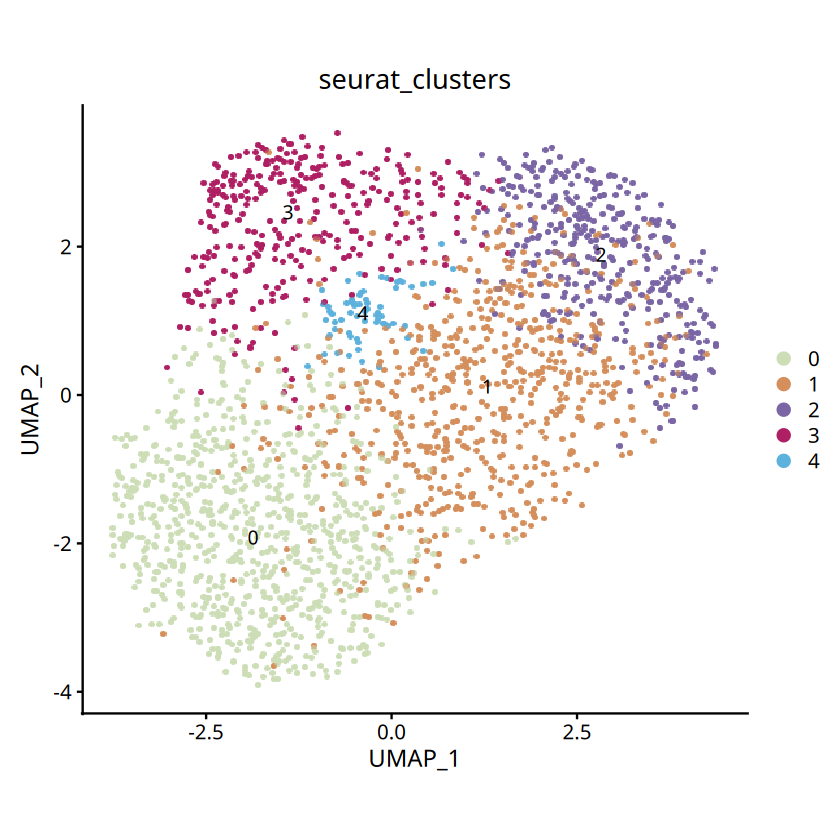

In [5]:
p <- DimPlot(obj_lung_ST,reduction = 'umap',group.by='seurat_clusters',pt.size = 3,raster=T,label=T)+
scale_color_manual(values = pal_igv()(50)[c(18,14,15,20,7)],breaks = sort(unique(obj_lung_ST$seurat_clusters)))+
coord_fixed()
p
pdf('Plot/Region_cluster/Lung_umap_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

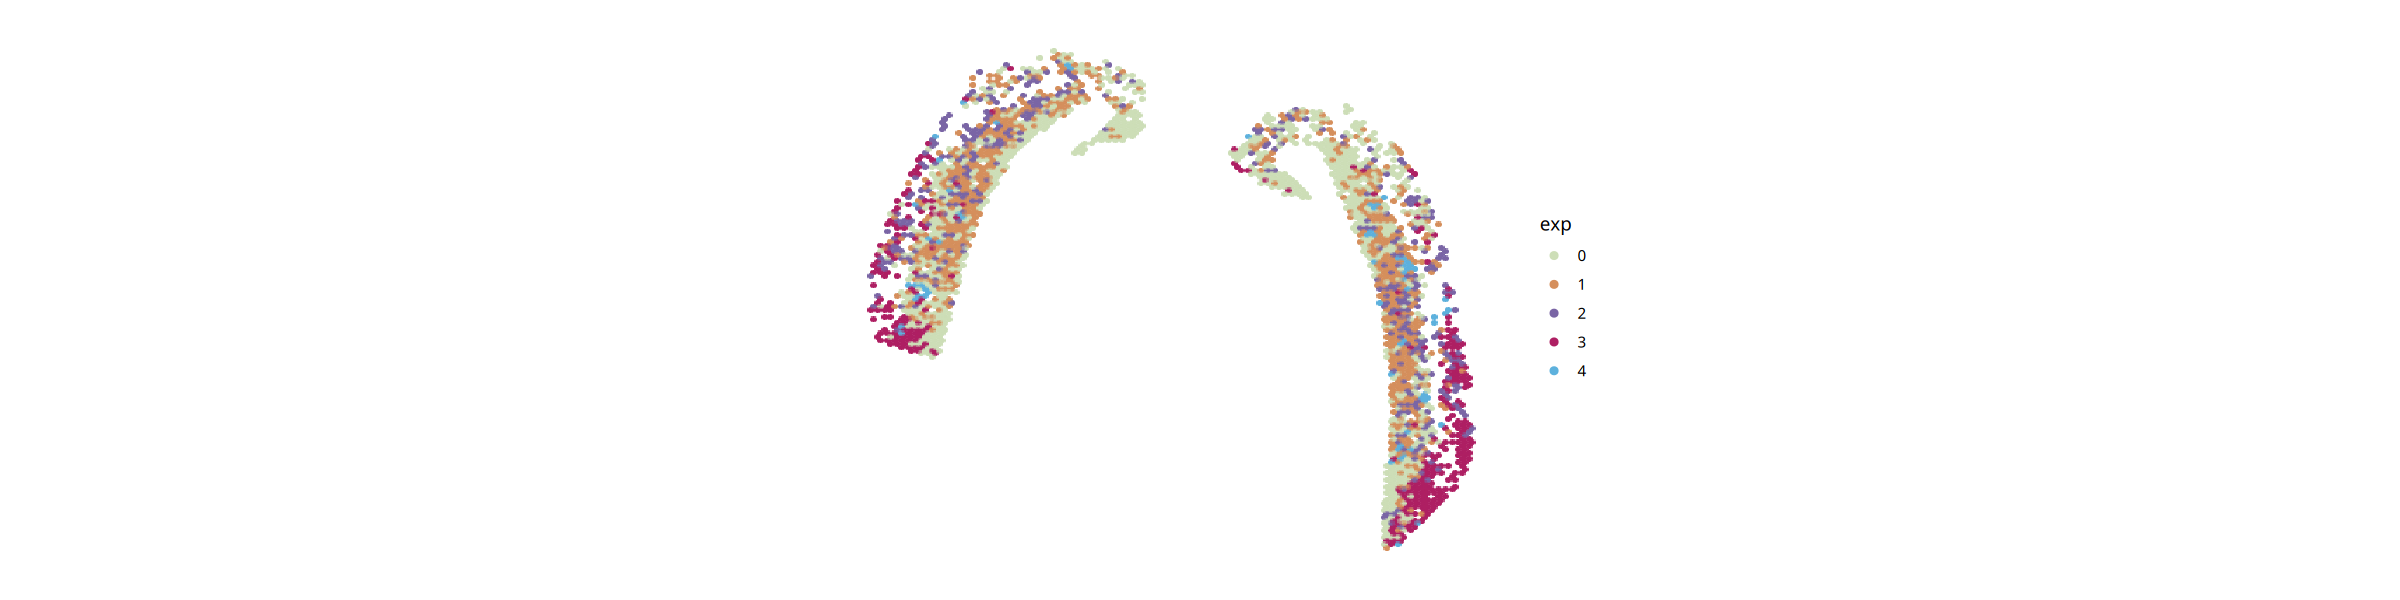

In [42]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'seurat_clusters')+
scale_color_manual(values = pal_igv()(50)[c(18,14,15,20,7)],breaks = sort(unique(obj_lung_ST$seurat_clusters)))
p
pdf('Plot/Region_cluster/Lung_spatial_cluster.pdf',height = 5,width = 20)
p
dev.off()

Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.


pdf 
  2

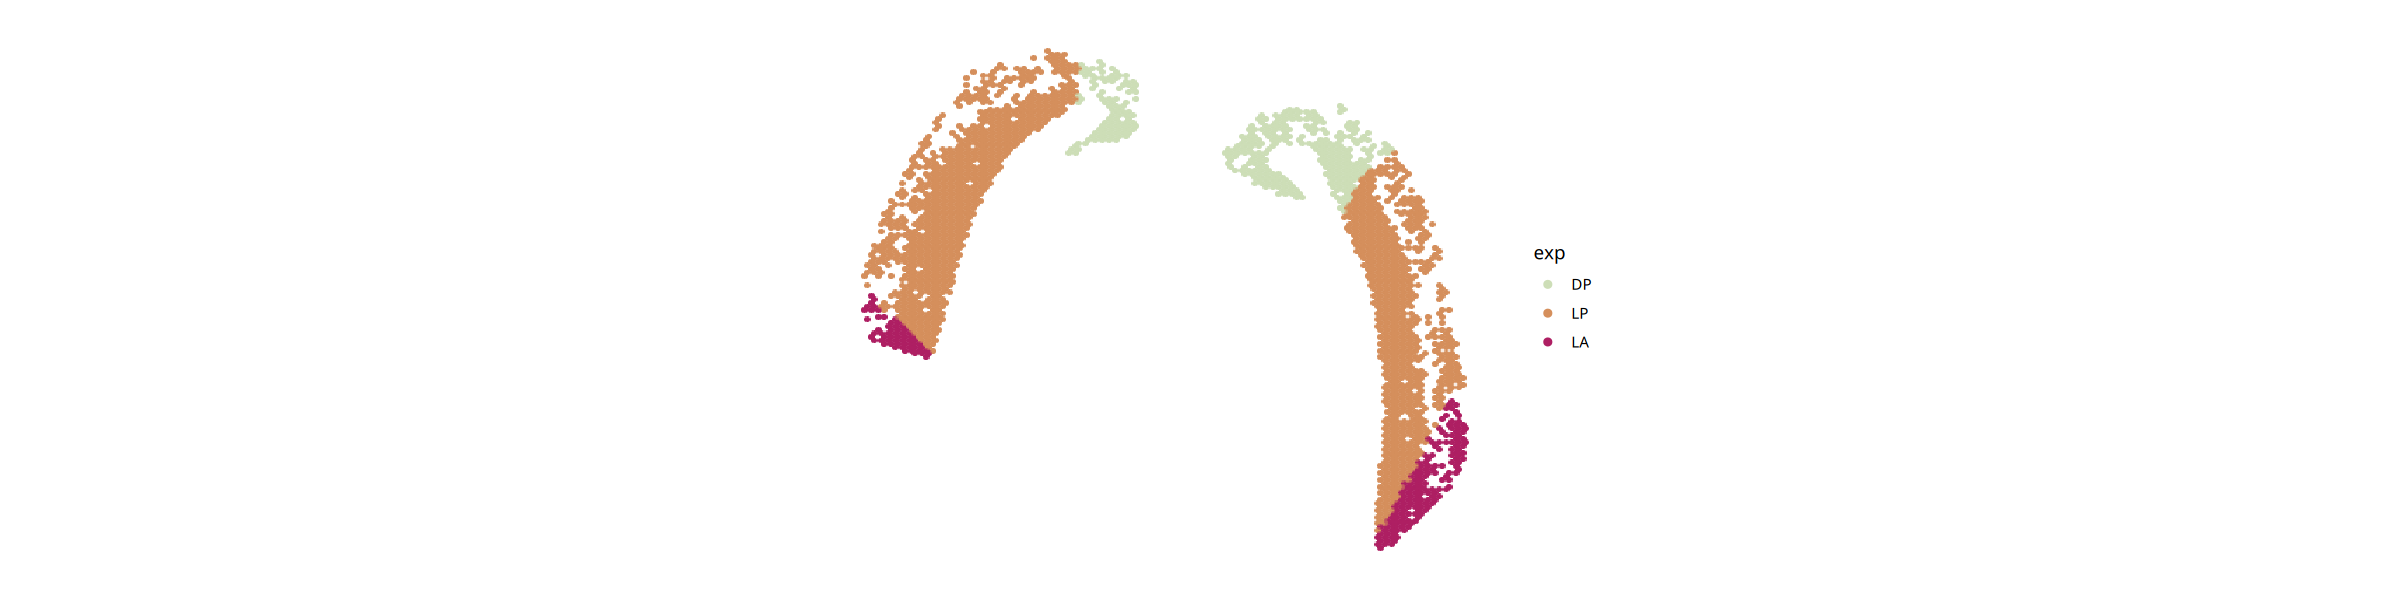

In [43]:
options(repr.plot.height=5,repr.plot.width=20)
p <- plot_spatial_col(obj = obj_lung_ST@meta.data,col_name = 'region')+
scale_color_manual(values = pal_igv()(50)[c(18,14,20,7)],breaks = c('DP','LP','LA'))
p
pdf('Plot/Region_cluster/Lung_spatial_manual.pdf',height = 5,width = 20)
p
dev.off()

In [44]:
saveRDS(obj_lung_ST,'Analysis/Region_defined/Gene_lung_delMP.rds')

In [46]:
saveRDS( obj_lung_ST@reductions$pca,'Analysis/Region_defined/Redcution_lung_delMP.rds')